<a href="https://colab.research.google.com/github/Andres-Gress/Simulacion-I/blob/main/TIBASA_SIMU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TIBASA
---
La empresa TIBASA (Fabricante de tinas de baño) tiene asignado un camión especial para el transporte de tinas terminadas. Dicho camión transporta diariamente 5 tinas. El peso de cada tina sigue la distribución triangular de la imagen anexa.

Si la capacidad del camión es de 1 tonelada, ¿cuál es la probabilidad de que el peso de las tinas exceda la capacidad del camión?

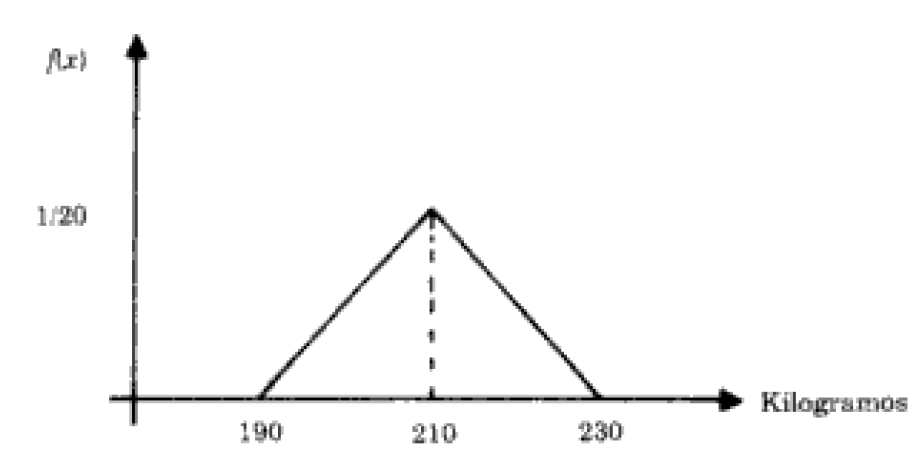

---

###SOLUCIÓN

#### PASO 1. VARIABLES

Peso de las tinas

$$x_1, x_2, x_3, x_4, x_5$$

donde

$$x_i \sim triangular(a,b,c)$$

donde $a= 190, b=230, c= 210$

Necesitamos la suma:

$$S=x_1+x_2+x_3+x_4+x_5$$

Y se debe cumplir que $\quad S \leq 1000$

Ahora, en base a estos datos, obtengamos la media (de una tina):

$$\mu = \frac{a+b+c}{3} = \frac{190+210+230}{3} = 210$$

Y también su desviación estandar (de una tina):

$$\sigma^2 = \frac{a^2+b^2+c^2-ab-ac-bc}{18} = \frac{36100 + 52900 + 44100 - 43700 - 39900 - 48300}{18} = \frac{1200}{18} = \frac{200}{3}$$

Entonces $$\sigma = \sqrt{\frac{200}{3}} \approx 8.16 $$

Además, por el teoerema central del límite se sabe que la suma de 5 variables independientes e identicamente distribuidas con media y varianzas finitas, es:

$$\frac{S_n - n \mu}{\sigma \sqrt{n}} → N(0,1)$$

Donde $$S_n=\Sigma x_i$$

Así, de la suma de las 5 tinas se tiene:

$$\mu=5(210)=1050$$

$$\sigma^2 = 5(\frac{200}{3}) = \frac{1000}{3} $$

$$⇒ \quad \sigma = \sqrt{\frac{1000}{3}} \approx 18.26$$

Entonces $$S_N \sim N(1050,18.26)$$

Y se quiere saber:

$$P(S>1000)$$

Estandarizamos:

$$Z = \frac{1000-n\mu}{\sqrt{n} \sigma } =\frac{1000-1050}{18.26} = -2.74$$

$$P(Z > -2.74) = 0.9969 $$

Esto quiere decir que analíticamente, la probabilidad de que la suma de los pesos de las 5 tinas es superior a 1000kg el 99.69% de las veces.

##SIMULACIÓN

In [67]:
import numpy as np
import random as r
import matplotlib.pyplot as plt

#### PASO 1. VARIABLES

Peso de las tinas

$$x_1, x_2, x_3, x_4, x_5$$

donde

$$x_i \sim triangular(a,b,c)$$

donde $a= 190, b=230, c= 210$


####PASO 4. DEFINIMOS EL MODELO

In [144]:
def tinas(a,b,c):
  lista = []
  for i in range(5):
    tina = r.triangular(a,b,c)
    lista.append(tina)
  s = sum(lista)
  return s

####PASO 5. DISEÑO DE UN EXPERIMENTO

In [148]:
a=190
b=230
c=210
tinas(a,b,c)

1058.1357601874222

Nótese que la mayoría de veces que se llama al experimento supera los 1000 kg, lo que se puede intuir deacuerdo al resultado teórico.

##PASO 6. REPETIR N VECES


In [215]:
def simulacion(n):
  contador = 0
  l = []
  for i in range(n):
    s = tinas(a,b,c)
    if s > 1000:
      contador += 1
    l.append(contador/(i+1))
  print(contador/n )
  return l

In [223]:
n=30000
M = simulacion(n)

0.9975


####PASO 7. GRÁFICA DE ESTABILIZACION

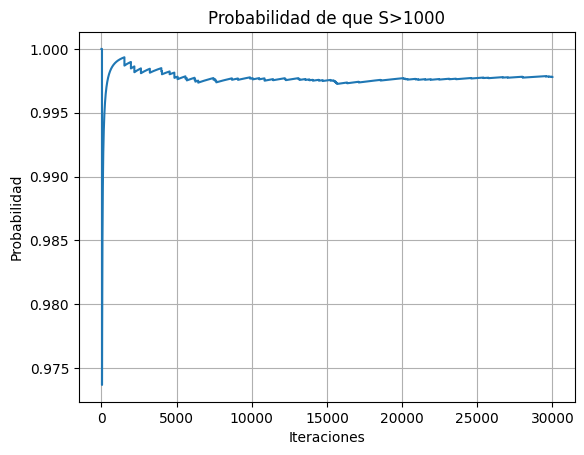

In [217]:
plt.plot(M)
plt.title("Probabilidad de que S>1000")
plt.xlabel("Iteraciones")
plt.ylabel("Probabilidad")
plt.grid()
plt.show()

####PASO 9. MEDIA Y VARIANZA

In [218]:
np.mean(M)

np.float64(0.9977030583556822)

In [219]:
np.std(M)

np.float64(0.000799228657679752)

####PASO 10. INTERVALO DE CONFIANZA AL 95%

Cada simulación es un experimento Bernoulli, que definiremos

exito si $s>1000$

fracaso si $s\leq 1000$

Entonces $$\hat{p} = \frac{x}{n}$$

Y el intervalo es

$$\hat{p} \pm 1.96 \sqrt{ \frac{\hat{p}(1-\hat{p})}{n}}$$

In [222]:
p = M[-1]

error = 1.96 * np.sqrt(p * (1 - p) / n)

IC = (p - error, p + error)
IC

(np.float64(0.9972698136599271), np.float64(0.998330186340073))

En conclusión, de acuerdo a la simulación, la probabilidad de que el peso de las 5 tinas supere los 1000 kg es de un 99.7%.

Un resultado muy similar a la teoría.
Por lo tanto se puede asumir que casi siempre las tinas van a superar la tonelada.